# 🎙️ Speech Emotion Recognition — CNN-BiLSTM Pipeline
**Datasets:** RAVDESS · TESS · IEMOCAP (optional)  
**Architecture:** Dual-stream CNN (Mel-spectrogram) + BiLSTM (MFCC) with fusion  

## 1 · Install & Import Dependencies

In [3]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "Pillow", "librosa", "scipy"], check=True)
print('Install step done.')

Install step done.


In [3]:
import os, sys, json, time, warnings
import pickle                          # ← for saving scalers
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Tuple, Dict, Optional
from PIL import Image
from scipy.stats import chi2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs       : {len(gpus)} → {[g.name for g in gpus]}')

TensorFlow : 2.19.0
GPUs       : 2 → ['/physical_device:GPU:0', '/physical_device:GPU:1']


## 2 · Configuration

In [4]:
CFG = {
    # Audio preprocessing
    'sample_rate'   : 22050,
    'duration'      : 3.0,
    'hop_overlap'   : 0.5,
    'trim_top_db'   : 20,

    # MFCC
    'n_mfcc'        : 40,
    'n_fft'         : 512,
    'hop_length'    : 256,
    'win_length'    : 512,

    # Mel-spectrogram
    'n_mels'        : 128,
    'mel_img_size'  : 128,

    # Augmentation (training only)
    'aug_noise_snr' : (15, 20),
    'aug_stretch'   : (0.9, 1.1),
    'aug_pitch'     : (-2, 2),

    # Splits
    'test_size'     : 0.15,
    'val_size'      : 0.15,

    # Training
    'batch_size'    : 32,
    'epochs'        : 100,
    'lr'            : 1e-3,
    'l2'            : 1e-4,
    'dropout_cnn'   : 0.3,
    'dropout_bilstm': 0.3,
    'dropout_dense' : 0.4,

    # Architecture
    'cnn_filters'   : [32, 64, 128],
    'bilstm_units'  : 128,
    'dense_units'   : 128,

    # Callbacks
    'lr_patience'   : 5,
    'lr_factor'     : 0.5,
    'es_patience'   : 15,

    # Output
    'output_dir'    : '/kaggle/working/ser_outputs',
}

os.makedirs(CFG['output_dir'], exist_ok=True)
print(f"Output directory: {CFG['output_dir']}")

EMOTION_MAPS = {
    'ravdess': {
        '01': 'neutral', '02': 'calm',    '03': 'happy',    '04': 'sad',
        '05': 'angry',   '06': 'fearful', '07': 'disgust',  '08': 'surprised'
    },
    'tess': {
        'angry': 'angry', 'disgust': 'disgust', 'fear': 'fearful',
        'happy': 'happy', 'ps': 'surprised',    'sad': 'sad', 'neutral': 'neutral'
    },
    'iemocap': {
        'neu': 'neutral', 'hap': 'happy', 'exc': 'happy',
        'sad': 'sad',     'ang': 'angry',
    }
}

Output directory: /kaggle/working/ser_outputs


## 3 · Dataset Discovery

In [5]:
def resolve_dataset_paths() -> Dict[str, Optional[str]]:
    """
    Resolves dataset paths in priority order:
      1. Kaggle UI attached datasets (/kaggle/input/...)
      2. Environment variable overrides (SER_*_PATH)
      3. kagglehub auto-download (RAVDESS & TESS only)
      IEMOCAP requires manual download due to licence agreement.
    """
    paths = {'ravdess': None, 'tess': None, 'iemocap': None}

    # ── 1. Kaggle UI attached datasets ───────────────────────────────────────
    kaggle_candidates = {
        'ravdess': [
            '/kaggle/input/ravdess-emotional-speech-audio',
            '/kaggle/input/ravdess',
        ],
        'tess': [
            '/kaggle/input/toronto-emotional-speech-set-tess',
            '/kaggle/input/tess',
        ],
        'iemocap': [
            '/kaggle/input/iemocapfullrelease',
            '/kaggle/input/iemocap-full-release',
            '/kaggle/input/iemocap',
        ],
    }

    for ds, candidates in kaggle_candidates.items():
        for c in candidates:
            if os.path.isdir(c):
                paths[ds] = c
                print(f'[OK]   {ds.upper():10s} → {c}')
                break

    # ── 2. Environment variable overrides ────────────────────────────────────
    env_keys = {
        'ravdess': 'SER_RAVDESS_PATH',
        'tess':    'SER_TESS_PATH',
        'iemocap': 'SER_IEMOCAP_PATH',
    }

    for ds, key in env_keys.items():
        if paths[ds] is None and os.environ.get(key):
            paths[ds] = os.environ[key]
            print(f'[ENV]  {ds.upper():10s} → {paths[ds]}')

    # ── 3. kagglehub auto-download fallback ──────────────────────────────────
    if paths['ravdess'] is None:
        try:
            import kagglehub
            p = kagglehub.dataset_download('uwrfkaggler/ravdess-emotional-speech-audio')
            paths['ravdess'] = p
            print(f'[HUB]  RAVDESS     → {p}')
        except Exception as e:
            print(f'[WARN] RAVDESS kagglehub download failed: {e}')

    if paths['tess'] is None:
        try:
            import kagglehub
            p = kagglehub.dataset_download('ejlok1/toronto-emotional-speech-set-tess')
            paths['tess'] = p
            print(f'[HUB]  TESS        → {p}')
        except Exception as e:
            print(f'[WARN] TESS kagglehub download failed: {e}')

    # ── IEMOCAP: licence-gated, manual download only ─────────────────────────
    if paths['iemocap'] is None:
        print(
            '[MISS] IEMOCAP     → not found.\n'
            '       Obtain from https://sail.usc.edu/iemocap/ (licence required)\n'
            '       then set: export SER_IEMOCAP_PATH=/path/to/IEMOCAP_full_release'
        )

    # ── Summary ──────────────────────────────────────────────────────────────
    found = sum(v is not None for v in paths.values())
    print(f'\n[INFO] {found}/3 datasets resolved.')
    return paths


dataset_paths = resolve_dataset_paths()

[HUB]  RAVDESS     → /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio
[HUB]  TESS        → /kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess
[MISS] IEMOCAP     → not found.
       Obtain from https://sail.usc.edu/iemocap/ (licence required)
       then set: export SER_IEMOCAP_PATH=/path/to/IEMOCAP_full_release

[INFO] 2/3 datasets resolved.


## 4 · Dataset Parsers

In [7]:
def parse_ravdess(root: str) -> pd.DataFrame:
    records = []
    for wav in Path(root).rglob('*.wav'):
        parts = wav.stem.split('-')
        if len(parts) < 7 or parts[0] != '03':
            continue
        label = EMOTION_MAPS['ravdess'].get(parts[2])
        if label:
            records.append({'path': str(wav), 'label': label, 'dataset': 'ravdess'})
    df = pd.DataFrame(records)
    print(f'[INFO] RAVDESS: {len(df)} files | {df["label"].nunique()} emotions')
    return df


def parse_tess(root: str) -> pd.DataFrame:
    records = []
    for wav in Path(root).rglob('*.wav'):
        folder = wav.parent.name.lower()
        for key, label in EMOTION_MAPS['tess'].items():
            if key in folder:
                records.append({'path': str(wav), 'label': label, 'dataset': 'tess'})
                break
    df = pd.DataFrame(records)
    print(f'[INFO] TESS: {len(df)} files | {df["label"].nunique()} emotions')
    return df


def parse_iemocap(root: str) -> pd.DataFrame:
    records = []
    for label_file in Path(root).rglob('*.txt'):
        if 'EmoEvaluation' not in label_file.name and '_' not in label_file.stem:
            continue
        try:
            text = label_file.read_text(errors='ignore')
        except Exception:
            continue
        for line in text.splitlines():
            line = line.strip()
            if not line.startswith('['):
                continue
            parts = line.split('\t')
            if len(parts) < 3:
                continue
            utt_id = parts[1].strip()
            emotion_raw = parts[2].strip().lower()
            label = EMOTION_MAPS['iemocap'].get(emotion_raw)
            if label is None:
                continue
            session = utt_id[:5]
            wav_path = (
                Path(root) / session / 'sentences' / 'wav' /
                utt_id.rsplit('_', 1)[0] / f'{utt_id}.wav'
            )
            if wav_path.exists():
                records.append({'path': str(wav_path), 'label': label, 'dataset': 'iemocap'})

    df = pd.DataFrame(records).drop_duplicates('path') if records else pd.DataFrame()
    print(f'[INFO] IEMOCAP: {len(df)} files | {df["label"].nunique() if len(df) else 0} emotions')
    return df


def build_master_dataframe(paths: Dict[str, Optional[str]]) -> pd.DataFrame:
    frames = []
    if paths.get('ravdess') and os.path.isdir(paths['ravdess']):
        frames.append(parse_ravdess(paths['ravdess']))
    if paths.get('tess') and os.path.isdir(paths['tess']):
        frames.append(parse_tess(paths['tess']))
    if paths.get('iemocap') and os.path.isdir(paths['iemocap']):
        frames.append(parse_iemocap(paths['iemocap']))

    if not frames:
        raise RuntimeError('No datasets found. Attach at least RAVDESS or TESS via Add Data.')

    df = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=42)
    print(f'\n[INFO] Total samples: {len(df)}')
    print(df['label'].value_counts().to_string())
    return df

[INFO] RAVDESS: 2880 files | 8 emotions
[INFO] TESS: 4800 files | 6 emotions

[INFO] Total samples: 7680
label
disgust      1184
happy        1184
sad          1184
angry        1184
fearful      1184
neutral       992
surprised     384
calm          384


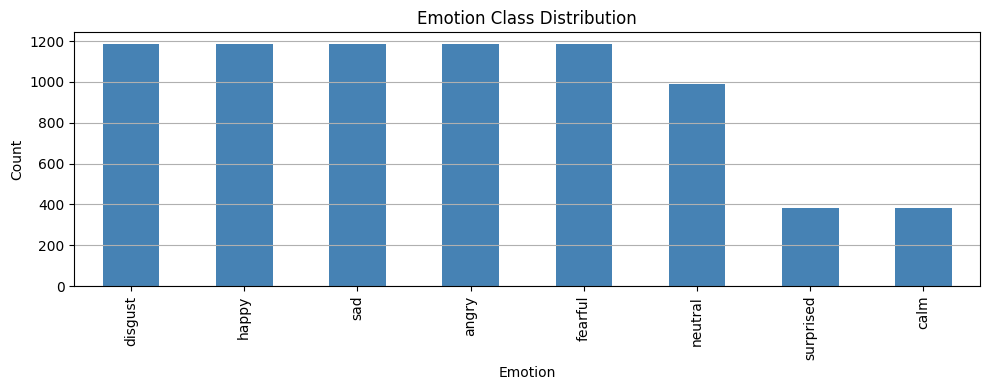

In [8]:
df = build_master_dataframe(dataset_paths)

fig, ax = plt.subplots(figsize=(10, 4))
df['label'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Emotion Class Distribution')
ax.set_xlabel('Emotion'); ax.set_ylabel('Count'); ax.grid(axis='y')
plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'class_distribution.png'), dpi=120)
plt.show()

## 5 · Audio Processing & Feature Extraction

In [9]:
def load_and_preprocess(path: str) -> Optional[np.ndarray]:
    try:
        y, sr = librosa.load(path, sr=CFG['sample_rate'], mono=True,
                             duration=CFG['duration'] * 2)
        y, _ = librosa.effects.trim(y, top_db=CFG['trim_top_db'])
        y = np.append(y[0], y[1:] - 0.97 * y[:-1])   # pre-emphasis
        target_len = int(CFG['sample_rate'] * CFG['duration'])
        y = np.pad(y, (0, max(0, target_len - len(y))))[:target_len]
        return y.astype(np.float32)
    except Exception as e:
        print(f'[WARN] Skipping {path}: {e}')
        return None


def extract_mfcc(y: np.ndarray) -> np.ndarray:
    """40 MFCCs + Δ + ΔΔ → (T, 120)"""
    mfcc   = librosa.feature.mfcc(y=y, sr=CFG['sample_rate'],
                                   n_mfcc=CFG['n_mfcc'],
                                   n_fft=CFG['n_fft'],
                                   hop_length=CFG['hop_length'],
                                   win_length=CFG['win_length'])
    delta  = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)
    return np.concatenate([mfcc, delta, delta2], axis=0).T.astype(np.float32)


def extract_mel_spectrogram(y: np.ndarray) -> np.ndarray:
    """Log-Mel spectrogram resized to (128, 128, 1)"""
    mel = librosa.feature.melspectrogram(
        y=y, sr=CFG['sample_rate'], n_mels=CFG['n_mels'],
        n_fft=CFG['n_fft'], hop_length=CFG['hop_length'],
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    img = Image.fromarray(log_mel).resize(
        (CFG['mel_img_size'], CFG['mel_img_size']))
    return np.array(img, dtype=np.float32)[..., np.newaxis]


def augment_audio(y: np.ndarray) -> np.ndarray:
    aug = np.random.choice(['noise', 'stretch', 'pitch'])
    target = int(CFG['sample_rate'] * CFG['duration'])
    if aug == 'noise':
        snr   = np.random.uniform(*CFG['aug_noise_snr'])
        power = np.mean(y ** 2)
        noise = np.random.normal(0, np.sqrt(power / (10 ** (snr / 10))), len(y))
        y = (y + noise).astype(np.float32)
    elif aug == 'stretch':
        rate = np.random.uniform(*CFG['aug_stretch'])
        y = librosa.effects.time_stretch(y, rate=rate)
        y = (y[:target] if len(y) > target
             else np.pad(y, (0, target - len(y)))).astype(np.float32)
    elif aug == 'pitch':
        steps = np.random.uniform(*CFG['aug_pitch'])
        y = librosa.effects.pitch_shift(
            y, sr=CFG['sample_rate'], n_steps=steps).astype(np.float32)
    return y


def extract_features(
    df: pd.DataFrame,
    augment: bool = False,
    label_encoder: Optional[LabelEncoder] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, LabelEncoder]:
    mfccs, mel_imgs, labels = [], [], []
    if label_encoder is None:
        label_encoder = LabelEncoder()
        label_encoder.fit(df['label'])

    print(f'[INFO] Extracting {len(df)} samples (augment={augment}) ...')
    t0 = time.time()

    for i, row in enumerate(df.itertuples(index=False), 1):
        y = load_and_preprocess(row.path)
        if y is None:
            continue
        if augment:
            y = augment_audio(y)
        mfccs.append(extract_mfcc(y))
        mel_imgs.append(extract_mel_spectrogram(y))
        labels.append(row.label)
        if i % 500 == 0:
            print(f'  {i}/{len(df)} ({time.time()-t0:.0f}s)')

    max_len = max(m.shape[0] for m in mfccs)
    mfccs_p = np.zeros((len(mfccs), max_len, 120), dtype=np.float32)
    for j, m in enumerate(mfccs):
        mfccs_p[j, :m.shape[0], :] = m

    mel_arr   = np.stack(mel_imgs, axis=0)
    labels_e  = label_encoder.transform(labels).astype(np.int32)
    print(f'[INFO] Done. MFCC: {mfccs_p.shape}  Mel: {mel_arr.shape}')
    return mfccs_p, mel_arr, labels_e, label_encoder


def fit_normalise(mfcc_train, mel_train):
    flat = mfcc_train.reshape(-1, mfcc_train.shape[-1])
    mfcc_scaler = StandardScaler().fit(flat)
    mel_mean = mel_train.mean()
    mel_std  = mel_train.std() + 1e-8
    return mfcc_scaler, mel_mean, mel_std


def apply_normalise(mfcc, mel, mfcc_scaler, mel_mean, mel_std):
    mfcc_n = mfcc_scaler.transform(mfcc.reshape(-1, mfcc.shape[-1])).reshape(mfcc.shape)
    mel_n  = (mel - mel_mean) / mel_std
    return mfcc_n.astype(np.float32), mel_n.astype(np.float32)

print('Feature functions defined.')

Feature functions defined.


## 6 · Train / Val / Test Split

In [10]:
le = LabelEncoder()
le.fit(df['label'])
num_classes = len(le.classes_)
print(f'Classes ({num_classes}): {list(le.classes_)}')

df_train, df_temp = train_test_split(
    df, test_size=CFG['test_size'] + CFG['val_size'],
    stratify=df['label'], random_state=42
)
df_val, df_test = train_test_split(
    df_temp,
    test_size=CFG['test_size'] / (CFG['test_size'] + CFG['val_size']),
    stratify=df_temp['label'], random_state=42
)
print(f'Split → train: {len(df_train)} | val: {len(df_val)} | test: {len(df_test)}')

Classes (8): ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Split → train: 5376 | val: 1152 | test: 1152


## 7 · Feature Extraction (this cell will take several minutes)

In [11]:
X_mfcc_tr, X_mel_tr, y_tr, le = extract_features(df_train, augment=True,  label_encoder=le)
X_mfcc_va, X_mel_va, y_va, _  = extract_features(df_val,   augment=False, label_encoder=le)
X_mfcc_te, X_mel_te, y_te, _  = extract_features(df_test,  augment=False, label_encoder=le)

[INFO] Extracting 5376 samples (augment=True) ...
  500/5376 (35s)
  1000/5376 (56s)
  1500/5376 (77s)
  2000/5376 (98s)
  2500/5376 (119s)
  3000/5376 (141s)
  3500/5376 (162s)
  4000/5376 (183s)
  4500/5376 (204s)
  5000/5376 (226s)
[INFO] Done. MFCC: (5376, 259, 120)  Mel: (5376, 128, 128, 1)
[INFO] Extracting 1152 samples (augment=False) ...
  500/1152 (13s)
  1000/1152 (25s)
[INFO] Done. MFCC: (1152, 259, 120)  Mel: (1152, 128, 128, 1)
[INFO] Extracting 1152 samples (augment=False) ...
  500/1152 (13s)
  1000/1152 (25s)
[INFO] Done. MFCC: (1152, 259, 120)  Mel: (1152, 128, 128, 1)


In [12]:
# Normalise
mfcc_scaler, mel_mean, mel_std = fit_normalise(X_mfcc_tr, X_mel_tr)

X_mfcc_tr, X_mel_tr = apply_normalise(X_mfcc_tr, X_mel_tr, mfcc_scaler, mel_mean, mel_std)
X_mfcc_va, X_mel_va = apply_normalise(X_mfcc_va, X_mel_va, mfcc_scaler, mel_mean, mel_std)
X_mfcc_te, X_mel_te = apply_normalise(X_mfcc_te, X_mel_te, mfcc_scaler, mel_mean, mel_std)

# Save scalers for deployment
scaler_data = {
    'mfcc_scaler': mfcc_scaler,
    'mel_mean':    float(mel_mean),
    'mel_std':     float(mel_std),
    'label_classes': list(le.classes_),
    'time_steps':  X_mfcc_tr.shape[1],
}
scaler_path = os.path.join(CFG['output_dir'], 'scaler_data.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler_data, f)
print(f'Scalers saved → {scaler_path}')

# Class weights
cw_array = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights = {i: w for i, w in enumerate(cw_array)}
print('Class weights:', class_weights)

Scalers saved → /kaggle/working/ser_outputs/scaler_data.pkl
Class weights: {0: np.float64(0.8106151990349819), 1: np.float64(2.4981412639405205), 2: np.float64(0.8106151990349819), 3: np.float64(0.8106151990349819), 4: np.float64(0.8106151990349819), 5: np.float64(0.968299711815562), 6: np.float64(0.8106151990349819), 7: np.float64(2.5074626865671643)}


## 8 · Feature Visualisation (sample check)

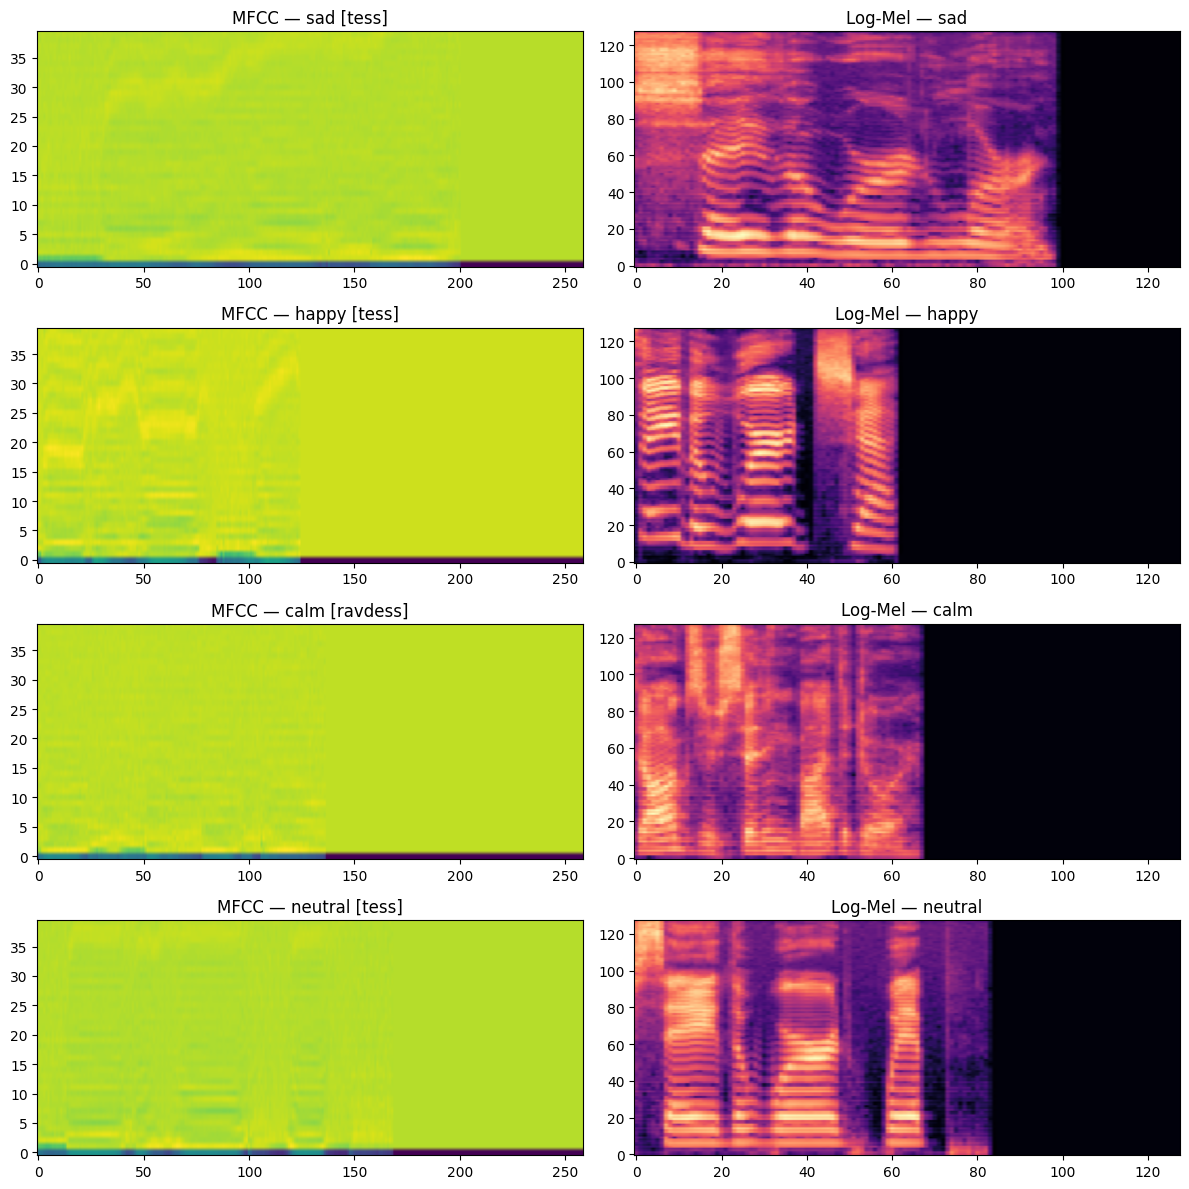

In [13]:
def visualise_features(df_sub, n_samples=4):
    sample = df_sub.sample(n=n_samples, random_state=0)
    fig, axes = plt.subplots(n_samples, 2, figsize=(12, 3 * n_samples))
    for i, (_, row) in enumerate(sample.iterrows()):
        y = load_and_preprocess(row['path'])
        if y is None:
            continue
        mfcc_feat = extract_mfcc(y)
        mel_feat  = extract_mel_spectrogram(y)

        axes[i, 0].imshow(mfcc_feat[:, :40].T, aspect='auto', origin='lower', cmap='viridis')
        axes[i, 0].set_title(f"MFCC — {row['label']} [{row['dataset']}]")

        axes[i, 1].imshow(mel_feat[:, :, 0], aspect='auto', origin='lower', cmap='magma')
        axes[i, 1].set_title(f"Log-Mel — {row['label']}")

    plt.tight_layout()
    plt.savefig(os.path.join(CFG['output_dir'], 'feature_examples.png'), dpi=120)
    plt.show()

visualise_features(df_train.head(20))

## 9 · Model Architecture (CNN-BiLSTM)

In [14]:
def build_cnn_bilstm(time_steps: int, num_classes: int) -> Model:
    # Stream A: CNN on Mel-spectrogram
    mel_input = layers.Input(shape=(128, 128, 1), name='mel_input')
    x = mel_input
    for filters in CFG['cnn_filters']:
        x = layers.Conv2D(filters, (3, 3), padding='same',
                          kernel_regularizer=regularizers.l2(CFG['l2']))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)
        x = layers.Dropout(CFG['dropout_cnn'])(x)
    x = layers.GlobalAveragePooling2D()(x)
    cnn_out = layers.Dense(128, activation='relu',
                           kernel_regularizer=regularizers.l2(CFG['l2']))(x)

    # Stream B: BiLSTM on MFCC
    mfcc_input = layers.Input(shape=(time_steps, 120), name='mfcc_input')
    y = layers.Masking(mask_value=0.0)(mfcc_input)
    y = layers.Bidirectional(
            layers.LSTM(CFG['bilstm_units'], return_sequences=True,
                        kernel_regularizer=regularizers.l2(CFG['l2'])))(y)
    y = layers.Dropout(CFG['dropout_bilstm'])(y)
    y = layers.Bidirectional(
            layers.LSTM(CFG['bilstm_units'], return_sequences=False,
                        kernel_regularizer=regularizers.l2(CFG['l2'])))(y)
    bilstm_out = layers.Dense(128, activation='relu',
                              kernel_regularizer=regularizers.l2(CFG['l2']))(y)

    # Fusion
    fused = layers.Concatenate()([cnn_out, bilstm_out])
    z = layers.Dense(CFG['dense_units'], activation='relu',
                     kernel_regularizer=regularizers.l2(CFG['l2']))(fused)
    z = layers.Dropout(CFG['dropout_dense'])(z)
    output = layers.Dense(num_classes, activation='softmax', name='emotion_output')(z)

    return Model(inputs=[mel_input, mfcc_input], outputs=output, name='CNN_BiLSTM_SER')


time_steps = X_mfcc_tr.shape[1]
model = build_cnn_bilstm(time_steps=time_steps, num_classes=num_classes)
model.summary()

I0000 00:00:1778342980.699002      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778342980.705018      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CNN_BiLSTM_SER"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mel_input           │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ mel_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mfcc_input          │ (None, 259, 120)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 259, 120)  │          0 │ mfcc_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 259, 120)  │          0 │ mfcc_input[0][0]

 Total params: 826,120 (3.15 MB)

 Trainable params: 825,672 (3.15 MB)

 Non-trainable params: 448 (1.75 KB)

## 10 · Training

In [15]:
checkpoint_path = os.path.join(CFG['output_dir'], 'best_model.keras')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CFG['lr']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=CFG['lr_factor'],
                      patience=CFG['lr_patience'], verbose=1, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=CFG['es_patience'],
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_loss',
                    save_best_only=True, verbose=0),
]

history = model.fit(
    x={'mel_input': X_mel_tr, 'mfcc_input': X_mfcc_tr},
    y=y_tr,
    validation_data=({'mel_input': X_mel_va, 'mfcc_input': X_mfcc_va}, y_va),
    batch_size=CFG['batch_size'],
    epochs=CFG['epochs'],
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100


E0000 00:00:1778343062.092189      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CNN_BiLSTM_SER_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1778343062.773753     147 cuda_dnn.cc:529] Loaded cuDNN version 91002


168/168 ━━━━━━━━━━━━━━━━━━━━ 26s 95ms/step - accuracy: 0.4060 - loss: 1.7355 - val_accuracy: 0.7309 - val_loss: 0.8739 - learning_rate: 0.0010
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.7442 - loss: 0.8546 - val_accuracy: 0.7509 - val_loss: 0.8227 - learning_rate: 0.0010
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.8059 - loss: 0.6733 - val_accuracy: 0.7960 - val_loss: 0.7265 - learning_rate: 0.0010
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.8547 - loss: 0.5355 - val_accuracy: 0.8368 - val_loss: 0.6223 - learning_rate: 0.0010
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.8920 - loss: 0.4373 - val_accuracy: 0.8377 - val_loss: 0.6811 - learning_rate: 0.0010
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.9144 - loss: 0.3855 - val_accuracy: 0.8420 - val_loss: 0.7232 - learning_rate: 0.0010
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - accuracy: 0.9405 - loss: 

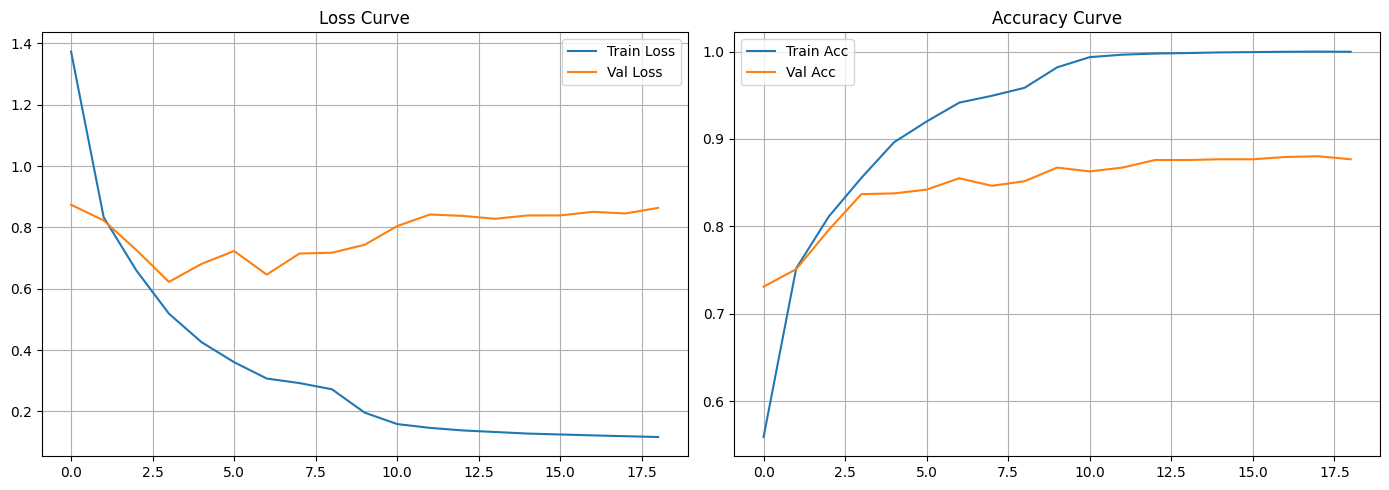

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy Curve'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'training_history.png'), dpi=150)
plt.show()

## 11 · Evaluation

In [17]:
y_pred_proba = model.predict(
    {'mel_input': X_mel_te, 'mfcc_input': X_mfcc_te},
    batch_size=CFG['batch_size'], verbose=0
)
y_pred = np.argmax(y_pred_proba, axis=1)
class_names = le.classes_

wa  = accuracy_score(y_te, y_pred)
f1m = f1_score(y_te, y_pred, average='macro')
ua  = f1_score(y_te, y_pred, average='macro', labels=range(len(class_names)))

print('='*55)
print('  EVALUATION RESULTS')
print('='*55)
print(f'  Weighted Accuracy  (WA) : {wa*100:.2f}%')
print(f'  Unweighted Accuracy(UA) : {ua*100:.2f}%')
print(f'  Macro F1-Score          : {f1m*100:.2f}%')
print('='*55)
print(classification_report(y_te, y_pred, target_names=class_names))

  EVALUATION RESULTS
  Weighted Accuracy  (WA) : 81.42%
  Unweighted Accuracy(UA) : 80.06%
  Macro F1-Score          : 80.06%
              precision    recall  f1-score   support

       angry       0.86      0.85      0.85       177
        calm       0.55      0.84      0.67        57
     disgust       0.89      0.80      0.84       178
     fearful       0.93      0.78      0.85       178
       happy       0.85      0.78      0.82       178
     neutral       0.93      0.83      0.88       149
         sad       0.71      0.82      0.76       177
   surprised       0.65      0.88      0.74        58

    accuracy                           0.81      1152
   macro avg       0.79      0.82      0.80      1152
weighted avg       0.83      0.81      0.82      1152



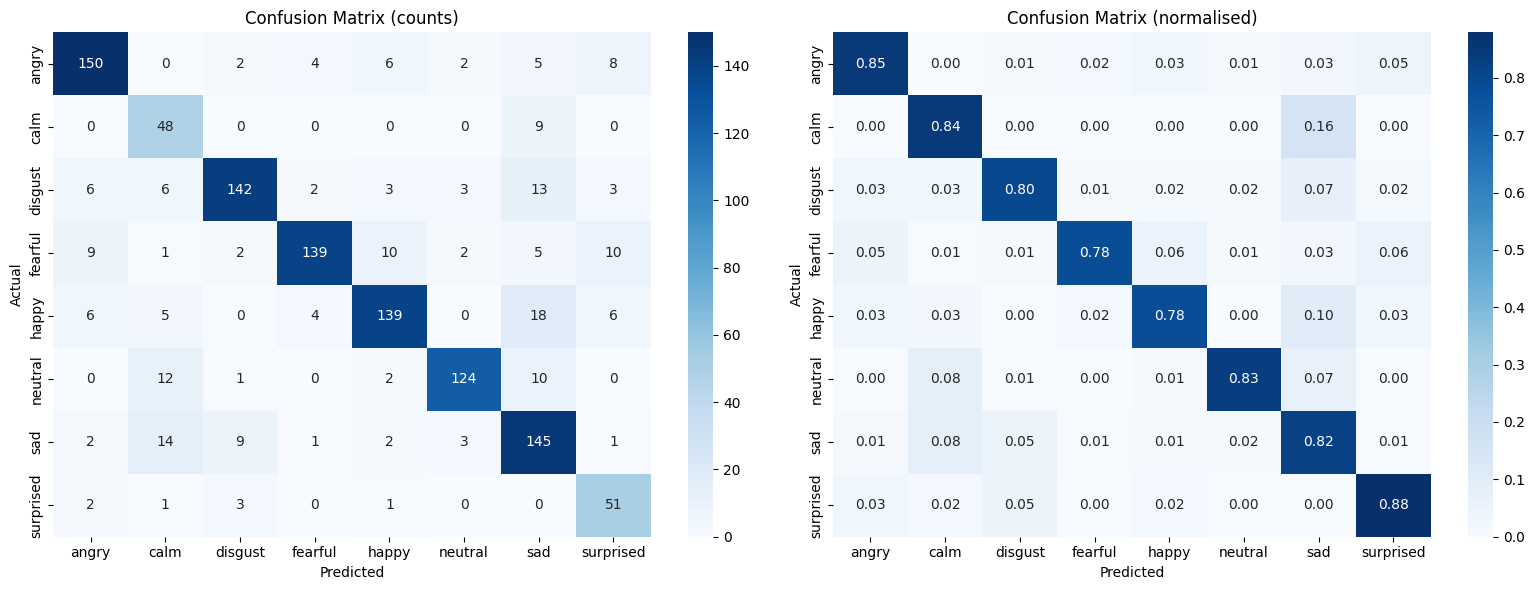

In [18]:
cm      = confusion_matrix(y_te, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)']
):
    sns.heatmap(data, annot=True, fmt=fmt, ax=ax,
                xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(CFG['output_dir'], 'confusion_matrix.png'), dpi=150)
plt.show()

## 12 · Save Model & Artefacts for Deployment

In [19]:
# Save final model
model_path = os.path.join(CFG['output_dir'], 'cnn_bilstm_ser_final.keras')
model.save(model_path)
print(f'Model saved → {model_path}')

# Save results JSON
results = {'weighted_accuracy': round(wa, 4),
           'unweighted_accuracy': round(ua, 4),
           'macro_f1': round(f1m, 4)}
with open(os.path.join(CFG['output_dir'], 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print('\n📦 Files in output dir:')
for p in sorted(Path(CFG['output_dir']).iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:<40s} {size_kb:>8.1f} KB')

print('\n✅ Download these files (Output tab) before deploying with Gradio:')
print('   • cnn_bilstm_ser_final.keras')
print('   • scaler_data.pkl')

Model saved → /kaggle/working/ser_outputs/cnn_bilstm_ser_final.keras

📦 Files in output dir:
  best_model.keras                           9818.6 KB
  class_distribution.png                       28.1 KB
  cnn_bilstm_ser_final.keras                 9818.6 KB
  confusion_matrix.png                        137.8 KB
  feature_examples.png                       1040.4 KB
  results.json                                  0.1 KB
  scaler_data.pkl                               3.4 KB
  training_history.png                         82.0 KB

✅ Download these files (Output tab) before deploying with Gradio:
   • cnn_bilstm_ser_final.keras
   • scaler_data.pkl


## 13 · Quick Inference Test
Test `predict_emotion()` on a random test file.

In [20]:
def predict_emotion(
    audio_path: str,
    model, label_encoder,
    mfcc_scaler, mel_mean, mel_std, time_steps
) -> Dict:
    y = load_and_preprocess(audio_path)
    if y is None:
        return {'error': 'Could not load audio'}

    mfcc = extract_mfcc(y)
    mel  = extract_mel_spectrogram(y)

    # Pad/trim MFCC to expected time_steps
    if mfcc.shape[0] < time_steps:
        mfcc = np.pad(mfcc, ((0, time_steps - mfcc.shape[0]), (0, 0)))
    else:
        mfcc = mfcc[:time_steps]

    mfcc_n = mfcc_scaler.transform(mfcc).astype(np.float32)
    mel_n  = ((mel - mel_mean) / mel_std).astype(np.float32)

    proba = model.predict(
        {'mel_input': mel_n[np.newaxis], 'mfcc_input': mfcc_n[np.newaxis]},
        verbose=0
    )[0]
    idx   = int(np.argmax(proba))
    return {
        'predicted_emotion': label_encoder.classes_[idx],
        'confidence':        round(float(proba[idx]), 4),
        'probabilities': {
            lbl: round(float(p), 4)
            for lbl, p in zip(label_encoder.classes_, proba)
        }
    }

# Test on a random sample
sample_row = df_test.sample(1).iloc[0]
result = predict_emotion(
    sample_row['path'], model, le,
    mfcc_scaler, mel_mean, mel_std, time_steps
)
print(f"File       : {sample_row['path']}")
print(f"True label : {sample_row['label']}")
print(f"Prediction : {result}")

File       : /kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_01/03-01-02-02-01-02-01.wav
True label : calm
Prediction : {'predicted_emotion': 'calm', 'confidence': 0.9243, 'probabilities': {'angry': 0.0003, 'calm': 0.9243, 'disgust': 0.0041, 'fearful': 0.0017, 'happy': 0.0023, 'neutral': 0.013, 'sad': 0.054, 'surprised': 0.0003}}
